# Creacion del Entorno

### Creamos nuestra estructura dentro de Unity Catalog

In [0]:
spark.sql("CREATE CATALOG IF NOT EXISTS sesion_1")
spark.sql("CREATE SCHEMA IF NOT EXISTS sesion_1.data")
spark.sql("CREATE VOLUME IF NOT EXISTS sesion_1.data.landing")

DataFrame[]

### Incorporar datos a un volumen

In [0]:
%sh
curl -L https://raw.githubusercontent.com/regarcia-magister/EAM-ETL-IA/refs/heads/main/sesion%201-2/data/nutrients_csvfile.csv -o /Volumes/sesion_1/data/landing/nutrients_csvfile.csv

%sh
curl -L https://raw.githubusercontent.com/regarcia-magister/EAM-ETL-IA/refs/heads/main/sesion%201-2/data/ventas_2025.csv -o /Volumes/sesion_1/data/landing/ventas_2025.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 19760  100 19760    0     0   3145      0  0:00:06  0:00:06 --:--:--  3144
bash: line 3: fg: no job control
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  3072  100  3072    0     0  11371      0 --:--:-- --:--:-- --:--:-- 11377


### Crear una Tabla

In [0]:
%sql
CREATE OR REPLACE TABLE sesion_1.data.tabla_simple (
  id INT,
  letra STRING,
  valor DOUBLE
);

INSERT INTO sesion_1.data.tabla_simple VALUES (1, 'A', 10.5), (2, 'B', 20), (3, 'C', 30.75);
SELECT * FROM sesion_1.data.tabla_simple

id,letra,valor
1,A,10.5
2,B,20.0
3,C,30.75


### Crear vista

In [0]:
%sql
CREATE OR REPLACE VIEW sesion_1.data.vw_tabla_simple_view AS
SELECT id,letra FROM sesion_1.data.tabla_simple
Where valor >15;

### Crear una funcion

In [0]:
spark.sql("CREATE SCHEMA IF NOT EXISTS sesion_1.security")

DataFrame[]

In [0]:
spark.sql("""
CREATE OR REPLACE FUNCTION sesion_1.security.fn_mayor_que_10(x DOUBLE)
RETURNS BOOLEAN
RETURN x > 10
""")

DataFrame[]

In [0]:
%sql
select * from sesion_1.data.tabla_simple
where sesion_1.security.fn_mayor_que_10(valor);

id,letra,valor
1,A,10.5
2,B,20.0
3,C,30.75


### Crear un dataFrame


In [0]:
path_data_demo = "/Volumes/sesion_1/data/landing/data_demo.csv"
df_demo= spark.read.csv(path_data_demo, header=True, inferSchema=True)

path_data_ventas = "/Volumes/sesion_1/data/landing/ventas_2025.csv"
df_ventas= spark.read.csv(path_data_ventas, header=True, inferSchema=True)


In [0]:
display(df_ventas)
#display(df_demo)

id,fecha,producto,cantidad,precio
1,2025-01-03,Teclado,20,25.99
2,2025-01-03,Webcam,1,39.99
3,2025-01-03,Auriculares,18,29.99
4,2025-01-04,Webcam,10,39.99
5,2025-01-04,Mouse,2,15.5
6,2025-01-05,Altavoces,13,45.0
7,2025-01-08,Teclado,11,25.99
8,2025-01-10,Auriculares,5,29.99
9,2025-01-11,Monitor,2,199.99
10,2025-01-12,Microfono,20,59.99


In [0]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType

schema = StructType([
    StructField("id", StringType(), True),
    StructField("fecha", StringType(), True),
    StructField("producto", StringType(), True),
    StructField("cantidad", IntegerType(), True),
    StructField("precio", DoubleType(), True)
])

df_csv = spark.read.csv(
    "/Volumes/sesion_1/data/landing/ventas_2025.csv",
    header=True,
    schema=schema,
    sep=","
)

### Guardar tabla delta

In [0]:
df_csv.write.format("delta").mode("overwrite").saveAsTable("sesion_1.data.producto")

In [0]:
%sql

select * from sesion_1.data.producto

id,fecha,producto,cantidad,precio
1,2025-01-03,Teclado,20,25.99
2,2025-01-03,Webcam,1,39.99
3,2025-01-03,Auriculares,18,29.99
4,2025-01-04,Webcam,10,39.99
5,2025-01-04,Mouse,2,15.5
6,2025-01-05,Altavoces,13,45.0
7,2025-01-08,Teclado,11,25.99
8,2025-01-10,Auriculares,5,29.99
9,2025-01-11,Monitor,2,199.99
10,2025-01-12,Microfono,20,59.99


### Modificar una tabla 

In [0]:
%sql

insert into sesion_1.data.producto (id,fecha,producto,cantidad,precio) 
values ('A001','2025-11-25','PC-0123',3 ,120000.50)

num_affected_rows,num_inserted_rows
1,1


### Update

In [0]:
%sql 

update sesion_1.data.producto 
set cantidad = 5,
    precio = 190000
where id = '1';
     
select * from sesion_1.data.producto

id,fecha,producto,cantidad,precio
2,2025-01-03,Webcam,1,39.99
3,2025-01-03,Auriculares,18,29.99
4,2025-01-04,Webcam,10,39.99
5,2025-01-04,Mouse,2,15.5
6,2025-01-05,Altavoces,13,45.0
7,2025-01-08,Teclado,11,25.99
8,2025-01-10,Auriculares,5,29.99
9,2025-01-11,Monitor,2,199.99
10,2025-01-12,Microfono,20,59.99
11,2025-01-12,USB,8,9.99


### Merge

In [0]:
from delta.tables import DeltaTable
from pyspark.sql import Row

# Obtener la tabla Delta
delta_table = DeltaTable.forName(spark, "sesion_1.data.producto")

# Crear un DataFrame con nuevos registros
nuevos_registros = [
    Row(id="3", fecha="2026-03-14", producto="ProductoX_SSS", cantidad=5, precio=99.5),
    Row(id="4", fecha="2026-03-14", producto="ProductoY_SSS", cantidad=10, precio=150.0)
]
df_nuevos = spark.createDataFrame(nuevos_registros)

# Realizar la operación MERGE
delta_table.alias("target").merge(
    df_nuevos.alias("source"),
    "target.id = source.id"
).whenMatchedUpdateAll() \
 .whenNotMatchedInsertAll() \
 .execute()

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
display(df_nuevos)

id,fecha,producto,cantidad,precio
3,2026-03-14,ProductoX_SSS,5,99.5
4,2026-03-14,ProductoY_SSS,10,150.0


### Time Travel

In [0]:
%sql

describe history sesion_1.data.producto

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
8,2026-03-26T00:38:02.000Z,77773195815916,holinicolas17@gmail.com,MERGE,"Map(predicate -> [""(id#12173 = id#12193)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [{""actionType"":""insert""}])",null,List(1531365892787435),0b0238ef-146c-49fe-90b2-c3d91403faae,0326-003609-3135jx5f-v2n,7,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 2, numTargetBytesAdded -> 2968, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 2, executionTimeMs -> 4746, materializeSourceTimeMs -> 205, numTargetRowsInserted -> 0, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 1, scanTimeMs -> 1794, numTargetRowsUpdated -> 2, numOutputRows -> 2, numTargetDeletionVectorsRemoved -> 1, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 2, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 2641)",null,Databricks-Runtime/18.0.x-aarch64-photon-scala2.13
7,2026-03-26T00:37:52.000Z,77773195815916,holinicolas17@gmail.com,UPDATE,"Map(predicate -> [""(id#11728 = 1)""])",null,List(1531365892787435),a391afe0-cc96-4b6e-be38-a4cd72e883f6,0326-003609-3135jx5f-v2n,6,WriteSerializable,false,"Map(numRemovedFiles -> 0, numRemovedBytes -> 0, numCopiedRows -> 0, numDeletionVectorsAdded -> 1, numDeletionVectorsRemoved -> 0, numAddedChangeFiles -> 0, executionTimeMs -> 5118, numDeletionVectorsUpdated -> 0, scanTimeMs -> 2450, numAddedFiles -> 1, numUpdatedRows -> 1, numAddedBytes -> 1453, rewriteTimeMs -> 2615)",null,Databricks-Runtime/18.0.x-aarch64-photon-scala2.13
6,2026-03-26T00:37:45.000Z,77773195815916,holinicolas17@gmail.com,WRITE,"Map(mode -> Append, statsOnLoad -> true, partitionBy -> [])",null,List(1531365892787435),daf02e15-2d85-42c4-a7f4-9c892b081b7a,0326-003609-3135jx5f-v2n,5,WriteSerializable,true,"Map(numFiles -> 1, numOutputRows -> 1, numOutputBytes -> 1437)",null,Databricks-Runtime/18.0.x-aarch64-photon-scala2.13
5,2026-03-26T00:37:39.000Z,77773195815916,holinicolas17@gmail.com,CREATE OR REPLACE TABLE AS SELECT,"Map(partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(1531365892787435),24166635-88de-4ce7-ba90-eb1f869ab642,0326-003609-3135jx5f-v2n,4,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 7, numRemovedBytes -> 11110, numDeletionVectorsRemoved -> 1, numOutputRows -> 100, numOutputBytes -> 2318)",null,Databricks-Runtime/18.0.x-aarch64-photon-scala2.13
4,2026-03-14T19:47:49.000Z,77773195815916,holinicolas17@gmail.com,MERGE,"Map(predicate -> [""(id#14967 = id#14987)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [{""actionType"":""insert""}])",null,List(1531365892787435),c13cc763-361d-4c86-8583-7bb1246aeea8,0314-184630-6s3qfq-v2n,3,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 2, numTargetBytesAdded -> 2964, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 2, executionTimeMs -> 3763, materializeSourceTimeMs -> 105, numTargetRowsInserted -> 0, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 1, scanTimeMs -> 1303, numTargetRowsUpdated -> 2, numOutputRows -> 2, numTargetDeletionVectorsRemoved -> 1, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 2, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewr

In [0]:
%sql

select * from sesion_1.data.producto version as of 1;

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-6882325775996973>, line 1
----> 1 sales_country_df = sales_with_total_df.sales_df.groupBy("country").agg(F,sum("units_sold").alias("total_units_sold"),F.sum("unit_price").alias("total_unit_price"))

NameError: name 'sales_with_total_df' is not defined

In [0]:
%sql

create table sesion_1.data.producto_v3
as select * from sesion_1.data.producto version as of 3;
    

select * from sesion_1.data.producto_v3

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-6882325775996974>, line 1
----> 1 get_ipython().run_cell_magic('sql', '', '\ncreate table sesion_1.data.producto_v3\nas select * from sesion_1.data.producto version as of 3;\n    \n\nselect * from sesion_1.data.producto_v3\n')

File /databricks/python/lib/python3.12/site-packages/IPython/core/interactiveshell.py:2541, in InteractiveShell.run_cell_magic(self, magic_name, line, cell)
   2539 with self.builtin_trap:
   2540     args = (magic_arg_s, cell)
-> 2541     result = fn(*args, **kwargs)
   2543 # The code below prevents the output from being displayed
   2544 # when using magics with decorator @output_can_be_silenced
   2545 # when the last Python token in the expression is a ';'.
   2546 if getattr(fn, magic.MAGIC_OUTPUT_CAN_BE_SILENCED, False):

File /databricks/python_shell/lib/dbruntime/sql_magic/sql_magic.py:192,

### Introduccion a Pyspark

In [0]:
spark.sql("CREATE SCHEMA IF NOT EXISTS sesion_1.sparkintro")
spark.sql("CREATE VOLUME IF NOT EXISTS sesion_1.sparkintro.landing")

DataFrame[]

In [0]:
%sh
curl -L https://raw.githubusercontent.com/regarcia-magister/EAM-ETL-IA/refs/heads/main/sesion%201-2/data/spark_intro.csv -o /Volumes/sesion_1/data/landing/spark_intro.csv

%sh
curl -L https://raw.githubusercontent.com/regarcia-magister/EAM-ETL-IA/refs/heads/main/sesion%201-2/data/dim_spark_intro.csv -o /Volumes/sesion_1/data/landing/dim_spark_intro.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   533  100   533    0     0    792      0 --:--:-- --:--:-- --:--:--   791
bash: line 3: fg: no job control
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   158  100   158    0     0    881      0 --:--:-- --:--:-- --:--:--   882


### Crear un DataFrame

In [0]:
sales_df = (spark.read
             .option("header", True)
             .option("inferSchema", True)
             .csv("/Volumes/sesion_1/data/landing/spark_intro.csv"))

display(sales_df)

order_id,order_date,country,product,category,units_sold,unit_price
1,2024-01-02,Spain,Laptop,Electronics,2,1200
2,2024-01-03,Spain,Mouse,Accessories,5,25
3,2024-01-05,France,Laptop,Electronics,1,1150
4,2024-01-06,Germany,Keyboard,Accessories,3,45
5,2024-01-07,Spain,Monitor,Electronics,2,300
6,2024-01-08,France,Mouse,Accessories,10,23
7,2024-01-10,Germany,Laptop,Electronics,1,1300
8,2024-01-11,Spain,Keyboard,Accessories,4,42
9,2024-01-12,France,Monitor,Electronics,1,280
10,2024-01-14,Germany,Mouse,Accessories,6,27


### Select(): elegir columnas 

In [0]:
sales_simple_df = (sales_df.select("order_id", "order_date", "country", "units_sold", "unit_price"))


display(sales_simple_df)

order_id,order_date,country,units_sold,unit_price
1,2024-01-02,Spain,2,1200
2,2024-01-03,Spain,5,25
3,2024-01-05,France,1,1150
4,2024-01-06,Germany,3,45
5,2024-01-07,Spain,2,300
6,2024-01-08,France,10,23
7,2024-01-10,Germany,1,1300
8,2024-01-11,Spain,4,42
9,2024-01-12,France,1,280
10,2024-01-14,Germany,6,27


### filter () / where (): filtrar filas 

In [0]:
from pyspark.sql import functions as F


In [0]:
#Filtrar por ventas españa

sales_spain_df = sales_df.filter(F.col("country") == "Spain")
display(sales_spain_df)

order_id,order_date,country,product,category,units_sold,unit_price
1,2024-01-02,Spain,Laptop,Electronics,2,1200
2,2024-01-03,Spain,Mouse,Accessories,5,25
5,2024-01-07,Spain,Monitor,Electronics,2,300
8,2024-01-11,Spain,Keyboard,Accessories,4,42


#### WithColumn(): crear o transformar columnas 

In [0]:
sales_with_total_df = sales_df.withColumn("total", F.col("units_sold") * F.col("unit_price"))
display(sales_with_total_df)

order_id,order_date,country,product,category,units_sold,unit_price,total
1,2024-01-02,Spain,Laptop,Electronics,2,1200,2400
2,2024-01-03,Spain,Mouse,Accessories,5,25,125
3,2024-01-05,France,Laptop,Electronics,1,1150,1150
4,2024-01-06,Germany,Keyboard,Accessories,3,45,135
5,2024-01-07,Spain,Monitor,Electronics,2,300,600
6,2024-01-08,France,Mouse,Accessories,10,23,230
7,2024-01-10,Germany,Laptop,Electronics,1,1300,1300
8,2024-01-11,Spain,Keyboard,Accessories,4,42,168
9,2024-01-12,France,Monitor,Electronics,1,280,280
10,2024-01-14,Germany,Mouse,Accessories,6,27,162


### GroupBY().agg() Agregaciones 

In [0]:
sales_country_df = sales_with_total_df.groupBy("country").agg(F.sum("units_sold").alias("total_units_sold"), F.sum("unit_price").alias("total_unit_price"))
display(sales_country_df)

country,total_units_sold,total_unit_price
Spain,13,1567
France,12,1453
Germany,10,1372


### join(): combinar datos de distintas tablas

In [0]:
products_din_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("/Volumes/sesion_1/data/landing/dim_spark_intro.csv")
)
display(products_din_df)


product,product_family,supplier
Laptop,Computers,TechCorp
Mouse,Peripherals,InputMakers
Keyboard,Peripherals,InputMakers
Monitor,Displays,ScreenWorld


In [0]:
sales_completo_df = (sales_with_total_df.alias("s")
                     .join(products_din_df.alias("p"),
                           on = "product",
                           how = "left"))
display(sales_completo_df)

product,order_id,order_date,country,category,units_sold,unit_price,total,product_family,supplier
Laptop,1,2024-01-02,Spain,Electronics,2,1200,2400,Computers,TechCorp
Mouse,2,2024-01-03,Spain,Accessories,5,25,125,Peripherals,InputMakers
Laptop,3,2024-01-05,France,Electronics,1,1150,1150,Computers,TechCorp
Keyboard,4,2024-01-06,Germany,Accessories,3,45,135,Peripherals,InputMakers
Monitor,5,2024-01-07,Spain,Electronics,2,300,600,Displays,ScreenWorld
Mouse,6,2024-01-08,France,Accessories,10,23,230,Peripherals,InputMakers
Laptop,7,2024-01-10,Germany,Electronics,1,1300,1300,Computers,TechCorp
Keyboard,8,2024-01-11,Spain,Accessories,4,42,168,Peripherals,InputMakers
Monitor,9,2024-01-12,France,Electronics,1,280,280,Displays,ScreenWorld
Mouse,10,2024-01-14,Germany,Accessories,6,27,162,Peripherals,InputMakers


In [0]:

sales_completo_df.write.format("delta").mode("overwrite").saveAsTable("sesion_1.sparkintro.sales_completo")

### 4 Analisis Exploratorio con Spark

4.1 Dimension, Tipos de Datos y primeras filas
Dimensiones: Indican la cantidad de observaciones y variables.
Tipos de datos: Es importante verificar que los tipos de datos sean los esperados (por ejemplo, numéricos para variables cuantitativas).
Primeras filas: Visualizar las primeras filas ayuda a entender la estructura y contenido de los datos.

In [0]:
# Número de filas y columnas
print(f"Dimensiones del DataFrame: {df_demo.count()} filas, {len(df_demo.columns)} columnas")

# Tipos de datos
df_demo.printSchema()

# Mostrar las primeras filas
df_demo.show(5)

Dimensiones del DataFrame: 8969 filas, 7 columnas
root
 |-- rooms: double (nullable = true)
 |-- garages: double (nullable = true)
 |-- useful_area: double (nullable = true)
 |-- value: double (nullable = true)
 |-- interior_quality: integer (nullable = true)
 |-- time_on_market: double (nullable = true)
 |-- has_outlier: integer (nullable = true)

+-----+-------+-----------+---------+----------------+------------------+-----------+
|rooms|garages|useful_area|    value|interior_quality|    time_on_market|has_outlier|
+-----+-------+-----------+---------+----------------+------------------+-----------+
|  3.0|    1.0|      105.0|1038640.0|               2|  31.7870789438591|          0|
|  3.0|    2.0|       76.0| 606405.0|               4|209.46884172046086|          0|
|  3.0|    1.0|      123.0|1534500.0|               1|              38.0|          0|
|  3.0|    2.0|      180.0|1131950.0|               5|             154.0|          0|
|  3.0|    1.0|       67.0| 452672.0|          

### 4.2 Verificacion de Nulos

In [0]:
from pyspark.sql.functions import isnan, when, count, col

display(
    df_demo.select([
    count(
        when(
            isnan(c), c
        )
    ).alias(c) for c in df_demo.columns])
)

rooms,garages,useful_area,value,interior_quality,time_on_market,has_outlier
0,0,0,0,0,0,0


## Importa funciones de PySpark:

isnan() → Detecta valores NaN (Not a Number).

when(condición, valor) → Crea una expresión condicional (similar a IF).

count() → Cuenta valores no nulos.

col() → Representa una columna.

En resumen: El count() cuenta cuántas veces hay NaN en esa columna, porque when() sólo devuelve algo cuando el valor es NaN.

### 4.3 Info Estadistica

### 4.3.1 Metodo Describe
El método describe() proporciona estadísticas básicas como el conteo, media, desviación estándar, mínimo y máximo para cada columna numérica del DataFrame.

In [0]:

df_demo.describe().show()

+-------+------------------+------------------+------------------+--------------------+------------------+-------------------+-------------------+
|summary|             rooms|           garages|       useful_area|               value|  interior_quality|     time_on_market|        has_outlier|
+-------+------------------+------------------+------------------+--------------------+------------------+-------------------+-------------------+
|  count|              8969|              8969|              8969|                8969|              8969|               8969|               8969|
|   mean| 2.904560151633404| 2.181960084736314|164.43251979038922|   2318303.109918609| 3.057308507079942| 183.75299388256192|0.06689708997658601|
| stddev|1.1767476369606926|1.7873402919148882| 242.3536366466504|1.2718375412767874E7|1.5081012065705974|  631.8837270473168|0.24985761913737123|
|    min|               1.0|               1.0|              0.63|               16.22|                 0|0.0605767031

### 4.3.2 Metodo Summary

In [0]:
display(df_demo.summary())

summary,rooms,garages,useful_area,value,interior_quality,time_on_market,has_outlier
count,8969,8969,8969,8969,8969,8969,8969
mean,2.904560151633404,2.181960084736314,164.43251979038922,2318303.109918609,3.057308507079942,183.75299388256192,0.06689708997658601
stddev,1.1767476369606926,1.7873402919148882,242.3536366466504,1.2718375412767874E7,1.5081012065705974,631.8837270473168,0.24985761913737123
min,1.0,1.0,0.63,16.22,0,0.06057670310490426,0
25%,2.0,1.0,78.0,712404.0,2,39.0,0
50%,3.0,2.0,120.0,1153020.0,3,96.0,0
75%,3.0,3.0,190.0,1935480.0,4,188.0,0
max,15.0,20.0,4909.06,2.9100819565E8,10,9588.87,1


### 4.3.3 Matriz de Correlacion

La matriz de correlación nos permite analizar la relación entre variables numéricas, mostrando qué columnas están más relacionadas entre sí (por ejemplo, si al aumentar precio también aumenta cantidad).

En Spark no podemos calcular la correlación directamente sobre varias columnas; primero debemos unir todas las columnas numéricas en un único vector usando VectorAssembler.
Luego, utilizamos la clase Correlation de Spark ML para calcular la correlación de Pearson de forma distribuida.

Finalmente, convertimos el resultado a Pandas para visualizar la matriz como un mapa de calor (heatmap), ya que Spark no tiene herramientas de visualización nativas.

Este enfoque combina: ✔️ Cálculo distribuido con Spark (rápido y escalable)
✔️ Visualización local con Python (pandas / seaborn)

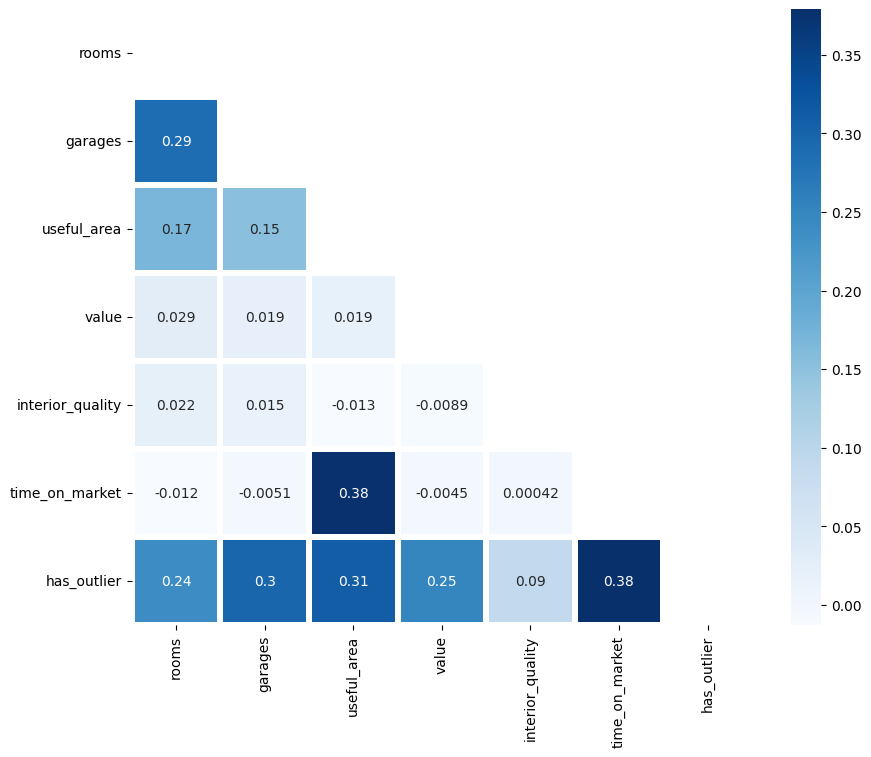

In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Seleccionar columnas numéricas de Spark
numeric_cols = [c for c, t in df_demo.dtypes if t in ("int", "bigint", "double", "float", "decimal")]

# 2. Crear columna vectorial para Spark ML
assembler = VectorAssembler(
    inputCols=numeric_cols,
    outputCol="features"
)
df_vector = assembler.transform(df_demo).select("features")

# 3. Calcular la matriz de correlación (Pearson) con Spark
corr_matrix_row = Correlation.corr(df_vector, "features", "pearson").head()
corr_matrix = corr_matrix_row[0].toArray()  # DenseMatrix -> NumPy array

# 4. Pasar la matriz a Pandas para visualizar
corr_df = pd.DataFrame(corr_matrix, index=numeric_cols, columns=numeric_cols)

# 5. Dibujar el heatmap (igual que antes)
pd.set_option('display.max_columns', None)

plt.figure(figsize=(10, 8))
mask_heatmap = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    data=corr_df,
    annot=True,
    linewidth=3,
    cmap='Blues',
    mask=mask_heatmap
)
plt.show()

### 4.3.4 Conteo de Outliers sobre la columna "time on market"

Un outlier (o valor atípico) es un punto de datos que se desvía significativamente del resto de las observaciones en un conjunto de datos. Estos valores pueden surgir por errores de medición, variaciones naturales o eventos poco comunes. Detectar y tratar los outliers es crucial, ya que pueden afectar negativamente la calidad de los modelos predictivos, sesgar estadísticas descriptivas y ocultar patrones importantes.​

El IQR mide la dispersión entre el primer (Q1) y el tercer cuartil (Q3) de los datos. Este método es robusto frente a distribuciones sesgadas y no requiere suposiciones sobre la forma de los datos
![image_1774488086436.png](./image_1774488086436.png "image_1774488086436.png")

In [0]:
from pyspark.sql import functions as F

# Calcular Q1 y Q3 usando approxQuantile (eficiente en Spark distribuido)
q1, q3 = df_demo.approxQuantile("time_on_market", [0.25, 0.75], 0.05)

# Calcular IQR
iqr = q3 - q1

# Definir límites inferior y superior usando la regla clásica
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Filtrar los outliers fuera de los límites
outliers = df_demo.filter(
    (F.col("time_on_market") < lower_bound) | 
    (F.col("time_on_market") > upper_bound)
)

# Mostrar los valores calculados
print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

# Mostrar los outliers detectados
display(outliers)

#Conteo de outliers
print(f"Total de outliers detectados: {outliers.count()}")

Q1: 41.0, Q3: 171.15613191013614, IQR: 130.15613191013614
Lower bound: -154.2341978652042, Upper bound: 366.3903297753403


rooms,garages,useful_area,value,interior_quality,time_on_market,has_outlier
3.0,3.0,88.0,790770.0,1,1767.99,1
3.0,3.0,320.0,2637470.0,3,3141.0,1
4.0,4.0,4515.35,2690950.0,3,2961.49,1
4.0,2.0,2215.9,1884900.0,1,3637.15,1
2.0,1.0,2339.28,746240.0,2,8108.72,1
4.0,4.0,1587.83,4177640.0,2,3012.89,1
3.0,1.0,1163.3,1288730.0,3,8628.81,1
4.0,3.0,407.0,3960300.0,4,673.49,1
4.0,3.0,170.0,726718.0,5,4431.11,1
3.0,2.0,86.0,1037420.0,5,927.61,1


Total de outliers detectados: 120


### 4.3.5 Z-Score
La puntuación Z indica cuántas desviaciones estándar se aleja un punto de la media. Valores con una Z-score mayor a 3 o menor a -3 suelen considerarse outliers.

In [0]:
from pyspark.sql import functions as F

# Calcular la media y la desviación estándar
mean_stddev = df_demo.select(
    F.mean("time_on_market").alias("mean"),
    F.stddev("time_on_market").alias("stddev")
).first()

mean_value = mean_stddev["mean"]
stddev_value = mean_stddev["stddev"]

# Calcular el Z-score
df_with_zscore = df_demo.withColumn(
    "zscore_time_on_market",
    (F.col("time_on_market") - mean_value) / stddev_value
)

# Filtrar los outliers
outliers = df_with_zscore.filter(
    (F.abs(F.col("zscore_time_on_market")) > 3)
)

# Mostrar los outliers
display(outliers)

rooms,garages,useful_area,value,interior_quality,time_on_market,has_outlier,zscore_time_on_market
3.0,3.0,320.0,2637470.0,3,3141.0,1,4.680049318465822
4.0,4.0,4515.35,2690950.0,3,2961.49,1,4.395962243081211
4.0,2.0,2215.9,1884900.0,1,3637.15,1,5.4652412434397775
2.0,1.0,2339.28,746240.0,2,8108.72,1,12.541812151342203
4.0,4.0,1587.83,4177640.0,2,3012.89,1,4.477306322379127
3.0,1.0,1163.3,1288730.0,3,8628.81,1,13.3648907934055
4.0,3.0,170.0,726718.0,5,4431.11,1,6.721738231754442
4.0,2.0,4476.24,1475740.0,2,2167.99,1,3.140193236799172
4.0,4.0,2171.44,4811560.0,2,8866.67,1,13.741320807059244
2.0,2.0,2341.11,906576.0,5,3652.68,1,5.489818549889128


### 5 DButils

dbutils es una utilidad interna de Databricks que proporciona comandos para interactuar con el entorno de ejecución de notebooks. Es muy útil para tareas como manipular archivos en DBFS, trabajar con secretos, ejecutar notebooks dentro de otros notebooks y más.

Se usa principalmente para:

Manejo de archivos (DBFS, Volumes).
Uso de secretos (credenciales, tokens).
Ejecutar y encadenar notebooks.
Añadir parámetros mediante widgets.

5.1 dbutils.fs → File System (DBFS)
Permite interactuar con el sistema de archivos de Databricks.

Comando	Función
dbutils.fs.ls(path)	Listar archivos
dbutils.fs.cp(src, dest)	Copiar
dbutils.fs.mv(src, dest)	Mover/Renombrar
dbutils.fs.rm(path, recurse=True)	Eliminar
dbutils.fs.mkdirs(path)	Crear carpeta


5.2 dbutils.secrets → Gestión de secretos
Permite acceder a credenciales de forma segura (sin hardcode).

Los secretos se guardan en:

Azure Key Vault
AWS Secrets Manager
Databricks Secret Scope
dbutils.secrets.get(scope="prod", key="mysql_password")

5.3 dbutils.notebook → Ejecutar notebooks desde otros
Para orquestar notebooks (pipelines, ETL, modularización).

dbutils.notebook.run("/Shared/Notebook_ETL", 60, {"input_date": "2025-11-25"})

### 5.4 dbutils.widgets → Parametrizar notebooks
Permiten crear entradas interactivas (parámetros) para hacer un notebook dinámico y reutilizable.
Tipos disponibles:

- text
- dropdown
- combobox
- multiselect

Acción	Comando
- Crear widget	dbutils.widgets.text(...)
- Obtener valor	dbutils.widgets.get("name")
- Obtener todos los valores	dbutils.widgets.getAll()
- Eliminar un widget	dbutils.widgets.remove("name")
- Eliminar todos los widgets	dbutils.widgets.removeAll()


### 5.5 Demo con Widgets
Para poder ver la utilidad de los widgets vamos a utilizar la ya creada tabla de productos. Crearemos distintos widgets para poder hacer consultas mediante estos parametros

###  5.5.1 Obtenemos productos unicos
Vamos a obtener todos los productos distintos y los almacenamos en una lista

In [0]:
# Cargar la tabla Delta registrada en el metastore
df = spark.table("sesion_1.data.producto")

# Obtener valores únicos de la columna 'producto'
lista_productos = [row['producto'] for row in df.select("producto").distinct().collect()]

lista_productos

['Webcam',
 'Mouse',
 'Altavoces',
 'Monitor',
 'Teclado',
 'Microfono',
 'USB',
 'Disco Duro',
 'Auriculares',
 'Impresora',
 'ProductoX_SSS',
 'ProductoY_SSS',
 'PC-0123']

### 5.5.2 Creamos un widget Dropdown

In [0]:
dbutils.widgets.dropdown(
    name="producto",
    defaultValue=lista_productos[0],   # First element as default
    choices=lista_productos
)

### 5.5.3 Creamos un widget multiselect

In [0]:

dbutils.widgets.multiselect(
  name='month_multiselect',
  defaultValue='1',
  choices=['1', '2', '3', '4','5','6','7','8','9','10','11','12'],
  label='Month of the Year'
)

### 5.5.4 Creamos un widget text para rango minimo de precios

In [0]:
dbutils.widgets.text("min_price", "0", "Precio mínimo")

### 5.5.5 Consulta con Parametros de Widget

In [0]:
from pyspark.sql.functions import col, avg, month


producto_sel = dbutils.widgets.get("producto")          # dropdown
min_price = float(dbutils.widgets.get("min_price"))     # text

months_str = dbutils.widgets.get("month_multiselect")    # ej: "1,2,3"
months_list = [int(m) for m in months_str.split(",")] if months_str else []

# 2) Cargar la tabla
df = spark.table("sesion_1.data.producto")

# 3) Aplicar filtros
df_filtrado = (
    df
    .filter(col("producto") == producto_sel)
    .filter(col("precio") >= min_price)
)
if months_list:
    df_filtrado = df_filtrado.filter(month(col("fecha")).isin(months_list))


# 4) Calcular precio medio
df_media = df_filtrado.agg(avg("precio").alias("precio_medio"))

display(df_media)

precio_medio
39.99


### 5.5.5.2 Con SQL

In [0]:
%sql
SELECT 
  AVG(precio) AS precio_medio
FROM 
  sesion_1.data.producto
WHERE 
  producto = :producto
  AND precio >= CAST(:min_price AS DOUBLE)
  AND MONTH(fecha) IN (
        SELECT CAST(col AS INT)
        FROM explode(split(:month_multiselect, ','))
      )

precio_medio
39.99


### 6 Creacion de Dashboard con SQL

In [0]:
%sql
SELECT * FROM sesion_1.data.producto;

id,fecha,producto,cantidad,precio
2,2025-01-03,Webcam,1,39.99
5,2025-01-04,Mouse,2,15.5
6,2025-01-05,Altavoces,13,45.0
7,2025-01-08,Teclado,11,25.99
8,2025-01-10,Auriculares,5,29.99
9,2025-01-11,Monitor,2,199.99
10,2025-01-12,Microfono,20,59.99
11,2025-01-12,USB,8,9.99
12,2025-01-12,Webcam,16,39.99
13,2025-01-13,USB,6,9.99


En Databricks podemos crear visualizaciones rápidas directamente desde los notebooks, lo que permite realizar una exploración gráfica inicial de los datos de forma sencilla y sin necesidad de código adicional.

Pasos para crear una visualización básica
Ejecuta una consulta o DataFrame, por ejemplo:

SELECT * FROM sesion1.data.productos;
Una vez ejecutado, debajo de la tabla de resultados, haz clic en el botón + y selecciona Visualization.

Se abrirá el editor de visualización, donde podrás elegir:

Tipo de gráfico (barras, líneas, pie, mapa, histogramas…)
Columnas para los ejes X e Y
Agrupaciones, agregaciones, filtros y estilos
Haz clic en Save para añadir la visualización a la celda.
💡 Estas visualizaciones son ideales para una exploración inicial (EDA) y permiten entender patrones, distribuciones o posibles anomalías de forma rápida.

### 6.2 Creacion de un Dashboard

In [0]:
%sql
-- 1. Crear la tabla con nombres y tipos de columnas
CREATE OR REPLACE TABLE sesion_1.data.dim_producto (
    product_id       INT,
    nombre_producto  STRING,
    categoria        STRING,
    tipo_dispositivo STRING,
    es_periferico    BOOLEAN,
    es_entrada       BOOLEAN,
    es_salida        BOOLEAN
)
USING DELTA;

-- 2. Insertar los datos
INSERT INTO sesion_1.data.dim_producto VALUES
    (1,  'Mouse',        'Accesorios',     'Entrada',         TRUE,  TRUE,  FALSE),
    (2,  'Teclado',      'Accesorios',     'Entrada',         TRUE,  TRUE,  FALSE),
    (3,  'Webcam',       'Multimedia',     'Entrada/Salida',  TRUE,  TRUE,  TRUE),
    (4,  'Microfono',    'Multimedia',     'Entrada',         TRUE,  TRUE,  FALSE),
    (5,  'Altavoces',    'Multimedia',     'Salida',          TRUE,  FALSE, TRUE),
    (6,  'Disco Duro',   'Almacenamiento', 'Almacenamiento',  FALSE, FALSE, FALSE),
    (7,  'Auriculares',  'Multimedia',     'Entrada/Salida',  TRUE,  TRUE,  TRUE),
    (8,  'USB',          'Accesorios',     'Almacenamiento',  FALSE, FALSE, FALSE),
    (9,  'Impresora',    'Oficina',        'Salida',          TRUE,  FALSE, TRUE),
    (10, 'Monitor',      'Oficina',        'Salida',          TRUE,  FALSE, TRUE);

num_affected_rows,num_inserted_rows
10,10


### 6.2.1 Creacion de Dashboard mediante consulta SQL